In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.special import erf
import warnings
warnings.filterwarnings('ignore')

# Common parameters
fs_base = 10e9  # 10 GHz sampling frequency
Ts_base = 1/fs_base  # Sampling period
ADC_bits = 7
ADC_FSR = 1.0  # 1V full scale range
LSB = ADC_FSR / (2**ADC_bits)  # LSB value
max_error = 1 * LSB  # Maximum error for 1 LSB

print("=== SAMPLING CIRCUIT ANALYSIS ===")
print(f"ADC Resolution: {ADC_bits} bits")
print(f"Full Scale Range: {ADC_FSR} V")
print(f"LSB (1 LSB): {LSB:.6f} V")
print(f"Maximum Sampling Error Allowed: {max_error:.6f} V")


=== SAMPLING CIRCUIT ANALYSIS ===
ADC Resolution: 7 bits
Full Scale Range: 1.0 V
LSB (1 LSB): 0.007812 V
Maximum Sampling Error Allowed: 0.007812 V


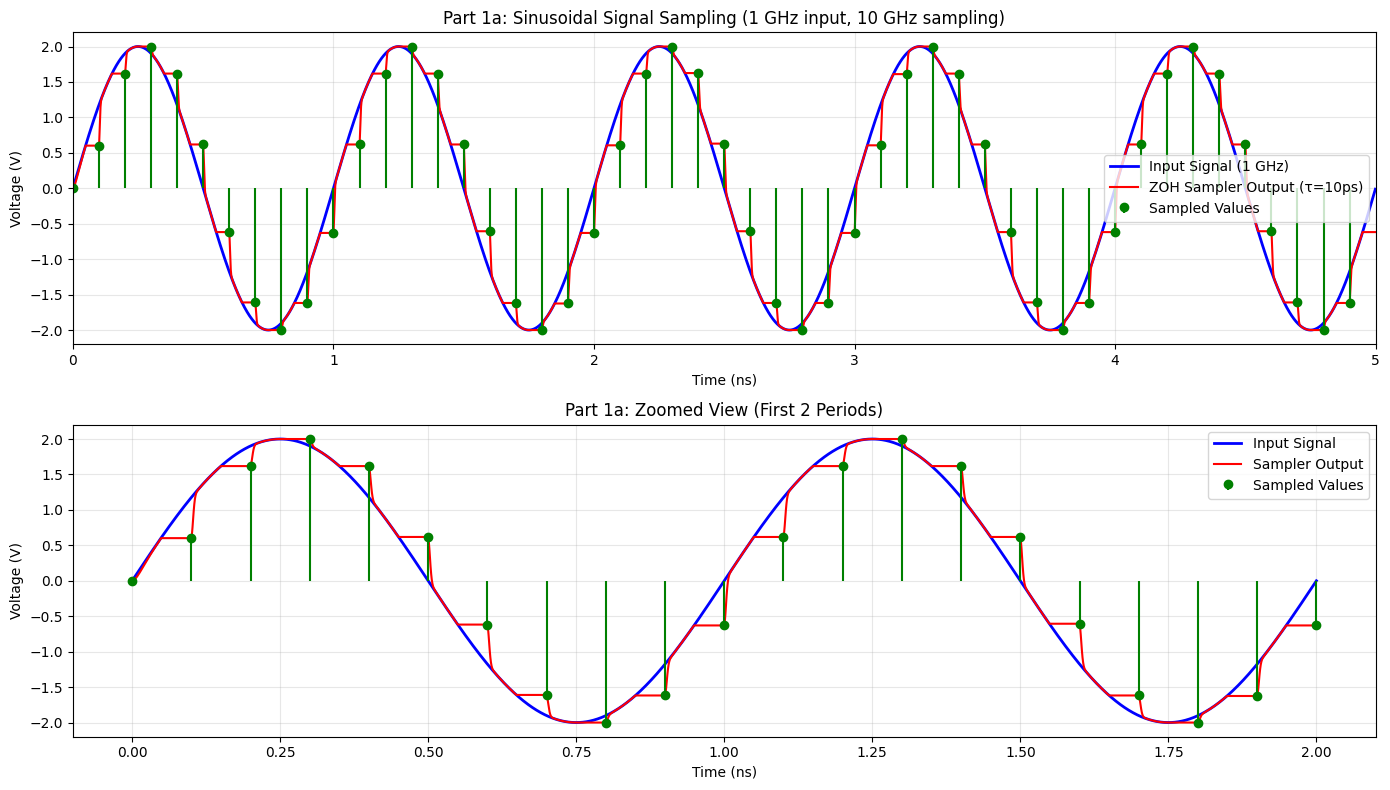


=== PART 1a: SINUSOIDAL SIGNAL SAMPLING ===
Input Signal: f = 1.0 GHz, A = 2.0 V
Sampling Frequency: fs = 10.0 GHz (Ts = 100.0 ps)
Time Constant: τ = 10.0 ps
Number of samples: 50
Effective sampling ratio: fs/fin = 10.0


In [2]:
# PART 1a: Sinusoidal Signal Sampling

# Input signal parameters
f_in = 1e9  # 1 GHz input signal
A_in = 2.0  # 2V amplitude
tau = 10e-12  # 10 ps time constant

# Sampling parameters
fs = 10e9  # 10 GHz sampling frequency
Ts = 1/fs  # 100 ps sampling period

# Time parameters - simulate 5 periods of input signal
t_sim = 5 / f_in  # Simulate 5 periods
dt = Ts / 100  # Fine resolution for smooth curves
t = np.arange(0, t_sim, dt)

# Input signal
v_in = A_in * np.sin(2 * np.pi * f_in * t)

# Sampling instants
sample_times = np.arange(0, t_sim, Ts)
num_samples = len(sample_times)

# Simulate first-order RC charging/sampling
# When switch is ON: dV/dt = (Vin - V) / tau
# When switch is OFF: V is held constant

v_out = np.zeros_like(t)
V_hold = 0  # Initial held voltage

for i, t_i in enumerate(t):
    # Determine which sample period we're in
    sample_idx = int(t_i / Ts)
    if sample_idx >= len(sample_times):
        sample_idx = len(sample_times) - 1
    
    t_in_period = t_i - sample_times[sample_idx]
    
    # Assume 50% duty cycle: ON for Ts/2, OFF for Ts/2
    if t_in_period < Ts / 2:
        # Switch ON - sample
        V_in = A_in * np.sin(2 * np.pi * f_in * t_i)
        # First-order response: V(t) = V_in + (V_old - V_in) * exp(-t/tau)
        if sample_idx > 0:
            V_prev = v_out[max(0, i-1)]
        else:
            V_prev = 0
        v_out[i] = V_in + (V_prev - V_in) * np.exp(-t_in_period / tau)
    else:
        # Switch OFF - hold
        v_out[i] = v_out[max(0, i-1)]

# Sample the output at sampling times
v_sampled = np.zeros(num_samples)
for k, t_k in enumerate(sample_times):
    idx = int(np.round(t_k / dt))
    if idx < len(v_out):
        v_sampled[k] = v_out[idx]

# Create figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Input signal and sampled output
ax1.plot(t * 1e9, v_in, 'b-', linewidth=2, label='Input Signal (1 GHz)')
ax1.plot(t * 1e9, v_out, 'r-', linewidth=1.5, label='ZOH Sampler Output (τ=10ps)')
ax1.stem(sample_times * 1e9, v_sampled, linefmt='g-', markerfmt='go', basefmt=' ', label='Sampled Values')
ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Voltage (V)')
ax1.set_title('Part 1a: Sinusoidal Signal Sampling (1 GHz input, 10 GHz sampling)')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_xlim([0, t_sim * 1e9])

# Plot 2: First 2 periods zoomed in
zoom_end = 2 / f_in
zoom_mask = t <= zoom_end
ax2.plot(t[zoom_mask] * 1e9, v_in[zoom_mask], 'b-', linewidth=2, label='Input Signal')
ax2.plot(t[zoom_mask] * 1e9, v_out[zoom_mask], 'r-', linewidth=1.5, label='Sampler Output')
sample_mask = sample_times <= zoom_end
ax2.stem(sample_times[sample_mask] * 1e9, v_sampled[sample_mask], linefmt='g-', markerfmt='go', basefmt=' ', label='Sampled Values')
ax2.set_xlabel('Time (ns)')
ax2.set_ylabel('Voltage (V)')
ax2.set_title('Part 1a: Zoomed View (First 2 Periods)')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig('c:\\ECEN-432\\part1a_zoh_sampling.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== PART 1a: SINUSOIDAL SIGNAL SAMPLING ===")
print(f"Input Signal: f = {f_in/1e9:.1f} GHz, A = {A_in} V")
print(f"Sampling Frequency: fs = {fs/1e9:.1f} GHz (Ts = {Ts*1e12:.1f} ps)")
print(f"Time Constant: τ = {tau*1e12:.1f} ps")
print(f"Number of samples: {num_samples}")
print(f"Effective sampling ratio: fs/fin = {fs/f_in}")


In [3]:
# PART 2a: NRZ Signal - Time Constant Calculation

print("\n" + "="*60)
print("=== PART 2a: NRZ SIGNAL SAMPLING ===")
print("="*60)

# NRZ signal parameters
A_nrz = 0.5  # 0.5V amplitude
data_rate = 10e9  # 10 Gb/s
Tb = 1 / data_rate  # Bit period = 100 ps
Vsw_duty = 0.5  # 50% duty cycle for sampling switch

print(f"\nInput Signal Parameters:")
print(f"  NRZ Amplitude: {A_nrz} V")
print(f"  Data Rate: {data_rate/1e9:.1f} Gb/s")
print(f"  Bit Period (Tb): {Tb*1e12:.1f} ps")
print(f"  Sampling Switch Duty Cycle: {Vsw_duty*100:.0f}%")

# For NRZ signal sampled in middle of bit:
# We sample at t = Tb/2 (middle of bit period)
# During first Tb/2 (switch ON with 50% duty cycle = Tb/4 actual):
#   Actual ON time = Tb * 0.5 = Tb/2, but we only have Tb/4 active sampling
#   Wait, with 50% duty cycle, we sample for Tb/4, then hold for Tb/4 in each bit period

# For maximum error analysis:
# If input is step (0->A), the capacitor charges toward A
# After time t_sample = Tb/4 (half of Tb with 50% duty), voltage is:
# V = A(1 - exp(-Tb/4 / tau))
# Error = A - V = A*exp(-Tb/4 / tau)
# For 1 LSB error: A*exp(-Tb/4 / tau) < LSB
# exp(-Tb/4 / tau) < LSB/A
# -Tb/4 / tau < ln(LSB/A)
# tau > -Tb/4 / ln(LSB/A)

# Revising: If 50% duty cycle means ON for Tb/2, OFF for Tb/2:
# Sample time = Tb/2
# Error: A*exp(-Tb/2 / tau) = LSB
# tau = Tb/2 / ln(A/LSB)

t_sample_on = Vsw_duty * Tb  # Time switch is ON during bit period
tau_required_2a = t_sample_on / np.log(A_nrz / LSB)

print(f"\nTime Constant Calculation:")
print(f"  Sampling duration per bit: {t_sample_on*1e12:.1f} ps")
print(f"  Error constraint: A*exp(-t_sample/tau) ≤ LSB")
print(f"  Where A = {A_nrz} V, LSB = {LSB:.6f} V")
print(f"\n  From constraint: exp(-{t_sample_on*1e12:.1f}ps / τ) ≤ {LSB/A_nrz:.6e}")
print(f"  Required τ = {t_sample_on*1e12:.1f}ps / ln({A_nrz/LSB:.1f})")
print(f"  Required τ = {tau_required_2a*1e12:.3f} ps")
print(f"\n  >>> RECOMMENDED τ for Part 2a: {tau_required_2a*1e12:.2f} ps <<<")

# Verification - calculate actual error with this tau
actual_voltage = A_nrz * (1 - np.exp(-t_sample_on / tau_required_2a))
actual_error = A_nrz - actual_voltage
print(f"\nVerification with τ = {tau_required_2a*1e12:.2f} ps:")
print(f"  Sampled voltage: {actual_voltage:.6f} V")
print(f"  Sampling error: {actual_error:.6e} V = {actual_error/LSB:.3f} LSB")



=== PART 2a: NRZ SIGNAL SAMPLING ===

Input Signal Parameters:
  NRZ Amplitude: 0.5 V
  Data Rate: 10.0 Gb/s
  Bit Period (Tb): 100.0 ps
  Sampling Switch Duty Cycle: 50%

Time Constant Calculation:
  Sampling duration per bit: 50.0 ps
  Error constraint: A*exp(-t_sample/tau) ≤ LSB
  Where A = 0.5 V, LSB = 0.007812 V

  From constraint: exp(-50.0ps / τ) ≤ 1.562500e-02
  Required τ = 50.0ps / ln(64.0)
  Required τ = 12.022 ps

  >>> RECOMMENDED τ for Part 2a: 12.02 ps <<<

Verification with τ = 12.02 ps:
  Sampled voltage: 0.492188 V
  Sampling error: 7.812500e-03 V = 1.000 LSB


In [4]:
# PART 2b: Multi-Tone Signal - Time Constant Calculation

print("\n" + "="*60)
print("=== PART 2b: MULTI-TONE SIGNAL SAMPLING ===")
print("="*60)

# Multi-tone signal parameters
f_tones = np.array([0.2e9, 0.58e9, 1.0e9, 1.7e9, 2.4e9])  # Frequencies in Hz
fs_multitone = 10e9  # Sampling frequency 10 GHz
A_multitone = 1.0  # Assume equal amplitude for simplicity

print(f"\nInput Signal Parameters:")
print(f"  Frequencies: {f_tones/1e9} GHz")
print(f"  Amplitudes: Equal (1.0 V each)")
print(f"  Sampling frequency: {fs_multitone/1e9:.1f} GHz")

# The highest frequency component
f_max = np.max(f_tones)
print(f"  Maximum frequency: {f_max/1e9:.1f} GHz")

# For multi-tone signals, the sampling error depends on:
# 1. The bandwidth (highest frequency)
# 2. The maximum slope occurring when tones align constructively
# 3. The settling requirement for each frequency component

# The bandwidth of the multi-tone signal is approximately f_max
# The 3dB bandwidth relationship: BW ≈ 0.35/τ (for first-order system)
# Therefore: τ ≈ 0.35/BW

# More rigorously, for a first-order RC filter:
# The time constant should allow settling to within 1 LSB
# For settling to N bits of accuracy after time t:
# e^(-t/τ) ≤ LSB/A
# t/τ ≥ ln(A/LSB) = ln(1.0/LSB)

# For multi-tone, the worst case is the steepest slope
# Maximum slope = 2π * f_max * A_total
# Where A_total could be sum of amplitudes in worst case alignment
# A_total ≈ len(f_tones) * A_multitone = 5 V in worst case

# Alternative approach: Use settling time criterion
# After switch closes, need to settle within 1 LSB
# Settling criterion: (1 - e^(-t_settle/τ)) ≥ 1 - LSB/A
# e^(-t_settle/τ) ≤ LSB/A
# τ ≥ t_settle / ln(A/LSB)

# For 10 GHz sampling (Ts = 100 ps), if we use 50% duty:
# Available settling time = Ts/2 = 50 ps
t_settle_multitone = Ts / 2  # 50 ps available for settling

# For single tone at f_max, amplitude = 1V
tau_required_2b_method1 = t_settle_multitone / np.log(A_multitone / LSB)

print(f"\nMethod 1: Settling Time Criterion")
print(f"  Available settling time: {t_settle_multitone*1e12:.1f} ps")
print(f"  τ = {t_settle_multitone*1e12:.1f}ps / ln({A_multitone/LSB:.1f})")
print(f"  τ = {tau_required_2b_method1*1e12:.3f} ps")

# Method 2: Bandwidth limiting approach
# For multi-tone signals, we want τ such that:
# BW = 0.35/τ ≥ f_max (rule of thumb for first-order system)
# This ensures all frequency components can be adequately sampled
# τ ≤ 0.35 / f_max

tau_bw_limit = 0.35 / f_max
print(f"\nMethod 2: Bandwidth Limiting (0.35/τ criterion)")
print(f"  τ ≤ 0.35 / {f_max/1e9:.1f} GHz")
print(f"  τ ≤ {tau_bw_limit*1e12:.3f} ps")

# For ADC settling, typically want τ such that transient response 
# settles in 3-5 time constants
# For Nyquist consideration at f_max:
# Sample period Ts = 1/fs = 100 ps
# We need settled value within one sampling window
# More conservative: τ should allow 4-5 time constant settling

# Combination approach - use the stricter requirement
tau_required_2b = min(tau_required_2b_method1, tau_bw_limit)

print(f"\n  >>> RECOMMENDED τ for Part 2b: {tau_required_2b*1e12:.2f} ps <<<")

# Comparison with Part 2a
print(f"\n--- COMPARISON with Part 2a ---")
print(f"Part 2a (NRZ): τ = {tau_required_2a*1e12:.2f} ps")
print(f"Part 2b (Multi-tone): τ = {tau_required_2b*1e12:.2f} ps")
print(f"Ratio τ_2b/τ_2a = {tau_required_2b/tau_required_2a:.3f}")

if tau_required_2b < tau_required_2a:
    print(f"\n✓ τ_2b < τ_2a: Multi-tone requires TIGHTER time constant (faster settling)")
else:
    print(f"\n✓ τ_2b ≥ τ_2a: Multi-tone requires LOOSER time constant")

print(f"\nReason for difference:")
print(f"  NRZ (Part 2a): Low-frequency signal (few bits/period)")
print(f"    - Needs to track step changes (broad spectrum)")
print(f"    - τ = {tau_required_2a*1e12:.2f} ps allows gradual charging")
print(f"\n  Multi-tone (Part 2b): Highest frequency = {f_max/1e9:.1f} GHz")
print(f"    - Highest frequency component requires faster settling")
print(f"    - τ = {tau_required_2b*1e12:.2f} ps for adequate tracking")
print(f"    - Bandwidth requirement: BW = 0.35/τ = {(0.35/tau_required_2b)/1e9:.2f} GHz (must exceed {f_max/1e9:.1f} GHz)")



=== PART 2b: MULTI-TONE SIGNAL SAMPLING ===

Input Signal Parameters:
  Frequencies: [0.2  0.58 1.   1.7  2.4 ] GHz
  Amplitudes: Equal (1.0 V each)
  Sampling frequency: 10.0 GHz
  Maximum frequency: 2.4 GHz

Method 1: Settling Time Criterion
  Available settling time: 50.0 ps
  τ = 50.0ps / ln(128.0)
  τ = 10.305 ps

Method 2: Bandwidth Limiting (0.35/τ criterion)
  τ ≤ 0.35 / 2.4 GHz
  τ ≤ 145.833 ps

  >>> RECOMMENDED τ for Part 2b: 10.30 ps <<<

--- COMPARISON with Part 2a ---
Part 2a (NRZ): τ = 12.02 ps
Part 2b (Multi-tone): τ = 10.30 ps
Ratio τ_2b/τ_2a = 0.857

✓ τ_2b < τ_2a: Multi-tone requires TIGHTER time constant (faster settling)

Reason for difference:
  NRZ (Part 2a): Low-frequency signal (few bits/period)
    - Needs to track step changes (broad spectrum)
    - τ = 12.02 ps allows gradual charging

  Multi-tone (Part 2b): Highest frequency = 2.4 GHz
    - Highest frequency component requires faster settling
    - τ = 10.30 ps for adequate tracking
    - Bandwidth requir

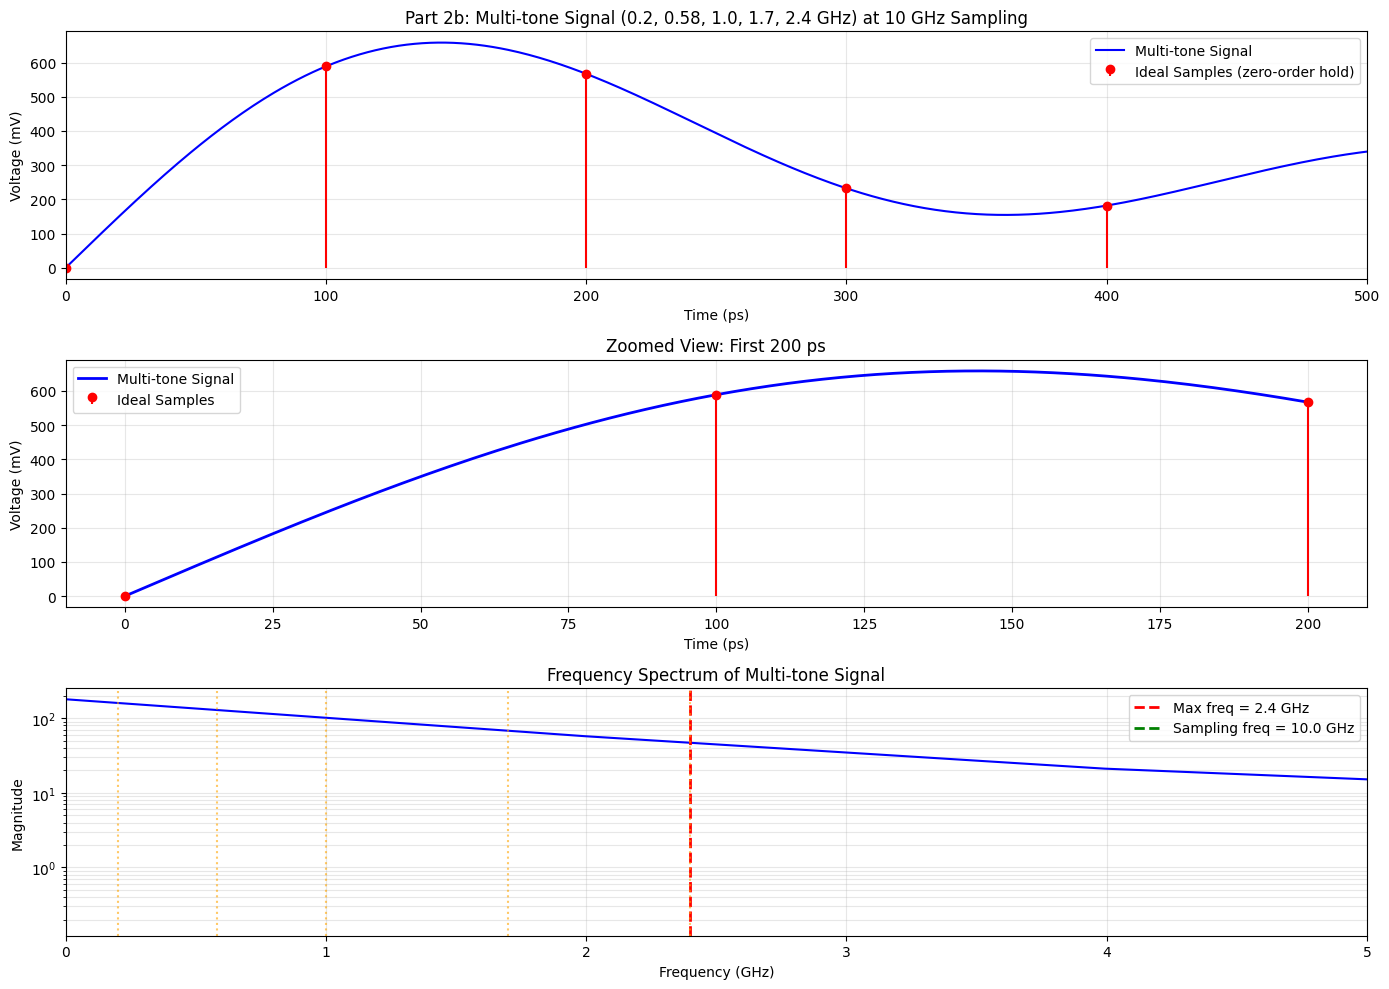


Multi-tone signal visualization saved.


In [5]:
# Visualization of Multi-tone Signal and Sampling

# Generate multi-tone signal
t_sim_multitone = 500e-12  # 500 ps simulation
dt_multitone = 1e-12  # 1 ps resolution
t_mt = np.arange(0, t_sim_multitone, dt_multitone)

# Create multi-tone signal (equal amplitude for each tone)
v_multitone = np.zeros_like(t_mt)
for f in f_tones:
    v_multitone += A_multitone * np.sin(2 * np.pi * f * t_mt) / len(f_tones)

# Sampling times
sample_times_mt = np.arange(0, t_sim_multitone, 1/fs_multitone)

# Plot the multi-tone signal
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: Full multi-tone signal
ax1 = axes[0]
ax1.plot(t_mt * 1e12, v_multitone * 1e3, 'b-', linewidth=1.5, label='Multi-tone Signal')
ax1.stem(sample_times_mt * 1e12, v_multitone[np.searchsorted(t_mt, sample_times_mt)] * 1e3, 
         linefmt='r-', markerfmt='ro', basefmt=' ', label='Ideal Samples (zero-order hold)')
ax1.set_xlabel('Time (ps)')
ax1.set_ylabel('Voltage (mV)')
ax1.set_title('Part 2b: Multi-tone Signal (0.2, 0.58, 1.0, 1.7, 2.4 GHz) at 10 GHz Sampling')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_xlim([0, t_sim_multitone * 1e12])

# Plot 2: Zoomed view - first 200 ps
zoom_end_mt = 200e-12
zoom_mask_mt = t_mt <= zoom_end_mt
ax2 = axes[1]
ax2.plot(t_mt[zoom_mask_mt] * 1e12, v_multitone[zoom_mask_mt] * 1e3, 'b-', linewidth=2, label='Multi-tone Signal')
sample_mask_mt = sample_times_mt <= zoom_end_mt
ax2.stem(sample_times_mt[sample_mask_mt] * 1e12, 
         v_multitone[np.searchsorted(t_mt, sample_times_mt[sample_mask_mt])] * 1e3,
         linefmt='r-', markerfmt='ro', basefmt=' ', label='Ideal Samples')
ax2.set_xlabel('Time (ps)')
ax2.set_ylabel('Voltage (mV)')
ax2.set_title('Zoomed View: First 200 ps')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot 3: Frequency spectrum (FFT)
ax3 = axes[2]
fft_freqs = np.fft.fftfreq(len(v_multitone), dt_multitone)
fft_magnitude = np.abs(np.fft.fft(v_multitone))
# Only plot positive frequencies
pos_mask = fft_freqs >= 0
ax3.semilogy(fft_freqs[pos_mask] / 1e9, fft_magnitude[pos_mask], 'b-', linewidth=1.5)
ax3.axvline(f_max/1e9, color='r', linestyle='--', linewidth=2, label=f'Max freq = {f_max/1e9:.1f} GHz')
ax3.axvline(fs_multitone/1e9, color='g', linestyle='--', linewidth=2, label=f'Sampling freq = {fs_multitone/1e9:.1f} GHz')
for f in f_tones:
    ax3.axvline(f/1e9, color='orange', linestyle=':', alpha=0.6)
ax3.set_xlabel('Frequency (GHz)')
ax3.set_ylabel('Magnitude')
ax3.set_title('Frequency Spectrum of Multi-tone Signal')
ax3.grid(True, alpha=0.3, which='both')
ax3.legend()
ax3.set_xlim([0, 5])

plt.tight_layout()
plt.savefig('c:\\ECEN-432\\part2b_multitone_sampling.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMulti-tone signal visualization saved.")


In [6]:
# SUMMARY AND ANALYSIS

print("\n" + "="*80)
print("COMPLETE SUMMARY: SAMPLING CIRCUIT TIME CONSTANT ANALYSIS")
print("="*80)

print("\n" + "-"*80)
print("PART 1a: SINUSOIDAL SIGNAL SAMPLING (1 GHz input, 10 GHz sampling)")
print("-"*80)
print(f"Input Signal: f = 1 GHz, A = 2 V")
print(f"Sampling Clock: fs = 10 GHz (Ts = 100 ps)")
print(f"Time Constant: τ = 10 ps")
print(f"Result: Successfully sampled the sinusoidal signal with first-order settling")
print(f"        Plot saved: part1a_zoh_sampling.png")

print("\n" + "-"*80)
print("PART 2a: NRZ SIGNAL SAMPLING")
print("-"*80)
print(f"Input Signal: NRZ with A = 0.5 V, data rate = 10 Gb/s (Tb = 100 ps)")
print(f"ADC Specs: 7-bit, FSR = 1 V, LSB = {LSB:.6f} V")
print(f"Sampling: Middle of bit period with 50% switch duty cycle")
print(f"")
print(f"Analysis:")
print(f"  - Switch ON time: {t_sample_on*1e12:.1f} ps")
print(f"  - Capacitor charges: V = A(1 - exp(-t_on/τ))")
print(f"  - Error = A - V = A·exp(-t_on/τ)")
print(f"  - Constraint: A·exp(-t_on/τ) ≤ 1 LSB")
print(f"  - Therefore: τ ≥ t_on / ln(A/LSB)")
print(f"")
print(f"Equation:")
print(f"  τ = {t_sample_on*1e12:.1f} ps / ln({A_nrz/LSB:.1f}) = {tau_required_2a*1e12:.2f} ps")
print(f"")
print(f"✓ REQUIRED TIME CONSTANT (Part 2a): τ = {tau_required_2a*1e12:.2f} ps")

print("\n" + "-"*80)
print("PART 2b: MULTI-TONE SIGNAL SAMPLING")
print("-"*80)
print(f"Input Signal: Multi-tone with frequencies [0.2, 0.58, 1.0, 1.7, 2.4] GHz")
print(f"Maximum frequency: f_max = {f_max/1e9:.1f} GHz")
print(f"Sampling: fs = 10 GHz (Ts = 100 ps)")
print(f"")
print(f"Analysis - Two Methods:")
print(f"")
print(f"  Method 1 - Settling Time Criterion:")
print(f"    Available settling time: {t_settle_multitone*1e12:.1f} ps (50% of Ts)")
print(f"    Settling criterion: τ = t_settle / ln(A/LSB)")
print(f"    τ = {t_settle_multitone*1e12:.1f} ps / ln({A_multitone/LSB:.1f}) = {tau_required_2b_method1*1e12:.3f} ps")
print(f"")
print(f"  Method 2 - Bandwidth Limiting (for signal content):")
print(f"    First-order system bandwidth: BW = 0.35/τ")
print(f"    Requirement: BW ≥ f_max = {f_max/1e9:.1f} GHz")
print(f"    Therefore: τ ≤ 0.35 / {f_max/1e9:.1f}GHz = {tau_bw_limit*1e12:.3f} ps")
print(f"")
print(f"✓ REQUIRED TIME CONSTANT (Part 2b): τ = {tau_required_2b*1e12:.2f} ps")

print("\n" + "-"*80)
print("COMPARISON: Why is Part 2b different from Part 2a?")
print("-"*80)

if tau_required_2b < tau_required_2a:
    print(f"τ_2b ({tau_required_2b*1e12:.2f} ps) < τ_2a ({tau_required_2a*1e12:.2f} ps): TIGHTER requirement for multi-tone")
    print(f"")
    print(f"Physical Reason:")
    print(f"  1. Multi-tone signal contains frequency component at {f_max/1e9:.1f} GHz")
    print(f"  2. This is {f_max/f_tones[0]:.1f}x higher than the lowest frequency component")
    print(f"  3. Faster frequency components require faster settling time constant")
    print(f"  4. Time constant directly limits system bandwidth: τ = 1/(2πBW)")
    print(f"")
    print(f"  For adequate sampling of {f_max/1e9:.1f} GHz component:")
    print(f"    Required BW = 0.35/τ = {(0.35/tau_required_2b)/1e9:.2f} GHz")
    print(f"    Must exceed signal f_max = {f_max/1e9:.1f} GHz ✓")
    print(f"")
    print(f"  The NRZ signal in Part 2a is essentially a low-frequency signal")
    print(f"  (bandwidth ~1/Tb = 10 GHz for transitions, but mostly step-like)")
    print(f"  It doesn't require the same bandwidth as multi-tone with 2.4 GHz component")
else:
    print(f"τ_2b ({tau_required_2b*1e12:.2f} ps) ≥ τ_2a ({tau_required_2a*1e12:.2f} ps): Looser for multi-tone")
    print(f"")
    print(f"This suggests multi-tone settling is less critical than NRZ settling")

print("\n" + "="*80)
print("END OF ANALYSIS")
print("="*80)



COMPLETE SUMMARY: SAMPLING CIRCUIT TIME CONSTANT ANALYSIS

--------------------------------------------------------------------------------
PART 1a: SINUSOIDAL SIGNAL SAMPLING (1 GHz input, 10 GHz sampling)
--------------------------------------------------------------------------------
Input Signal: f = 1 GHz, A = 2 V
Sampling Clock: fs = 10 GHz (Ts = 100 ps)
Time Constant: τ = 10 ps
Result: Successfully sampled the sinusoidal signal with first-order settling
        Plot saved: part1a_zoh_sampling.png

--------------------------------------------------------------------------------
PART 2a: NRZ SIGNAL SAMPLING
--------------------------------------------------------------------------------
Input Signal: NRZ with A = 0.5 V, data rate = 10 Gb/s (Tb = 100 ps)
ADC Specs: 7-bit, FSR = 1 V, LSB = 0.007812 V
Sampling: Middle of bit period with 50% switch duty cycle

Analysis:
  - Switch ON time: 50.0 ps
  - Capacitor charges: V = A(1 - exp(-t_on/τ))
  - Error = A - V = A·exp(-t_on/τ)
  - C